# 0. Imports & Outils 

## Choix et justification

**What** : Définir l’environnement d’exécution (librairies, config, seeds, affichage des versions)  
**Why** : Garantir une exécution stable et reproductible sur toutes les machines  
**How** : Centraliser les imports, fixer les seeds, normaliser la configuration projet

### Choix faits
- **Environnement unique** dans le notebook : tous les imports en tête pour éviter les surprises en lecture ou exécution.
- **Configuration centralisée** : chemins (`DATA_PATH`), séparateur CSV, seed (`RANDOM_STATE`), métrique cible fixés au début.
- **Seeds fixés** pour `random` et `numpy` → reproductibilité assurée.
- **Affichage explicite des versions** (`pandas`, `numpy`, `sklearn`, `imblearn`) → traçabilité.

###  Non-choix
- **Pas d’installation via pip** dans le notebook → à gérer en amont via `requirements.txt` pour éviter les conflits ou erreurs inattendues.
- **Pas de fichiers de config séparés** → overkill pour un MVP ; une cellule en tête suffit.
- **Pas de chargement distant** (cloud/URL) → travail 100% local, fiable et rapide.


In [1]:
# What : Ici je définis l’environnement d’exécution (librairies, config, seeds, versions)
# Why  : Parce que je veux garantir la reproductibilité et une exécution stable du notebook
# How  : Pour ce faire, je vais centraliser les imports, fixer les seeds et afficher les versions

# 1. J’importe les librairies essentielles
import numpy as np
import pandas as pd
import random
from sklearn import __version__ as sklearn_version
from imblearn import __version__ as imblearn_version

# 2. Je configure les chemins, le séparateur, le random_state
DATA_PATH = "../data/bank-full.csv"  # définit le chemin du fichier
SEPARATOR = ";"                      # définit le séparateur CSV
RANDOM_STATE = 42                    # fixe le seed

# 3. Je fixe les seeds pour Python et NumPy
random.seed(RANDOM_STATE)         # fixe le seed Python
np.random.seed(RANDOM_STATE)      # fixe le seed NumPy

# 4. J’affiche les versions des librairies
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn_version}")
print(f"imbalanced-learn: {imblearn_version}")


pandas: 2.3.1
numpy: 2.2.6
scikit-learn: 1.7.1
imbalanced-learn: 0.14.0


# 1. Chargement du dataset

## Choix et justification

**What**  
Charger les données brutes depuis un fichier local.

**Why**  
Débloquer rapidement tout problème de lecture ou de format et valider que les colonnes attendues sont bien présentes.

**How**  
Utiliser `pandas.read_csv()` avec les bons paramètres (chemin relatif, séparateur, encodage) et faire des vérifications simples.

### Choix faits
- Chemin relatif : `../data/bank-full.csv` (structure standard du projet)
- Séparateur : `;` (conforme au format original du dataset UCI Bank Marketing)
- Encodage : `utf-8` par défaut (ajustable si besoin)
- Vérifications immédiates :
  - Taille du dataset avec `.shape`
  - Affichage d’un échantillon avec `.head()`
  - Présence de la colonne cible `y`

### Non-choix
- Lecture en morceaux (`chunksize`) : inutile, le dataset tient en RAM
- Téléchargement en ligne : évité, les fichiers sont déjà dans le repo local


In [2]:
# What : Ici je charge les données brutes du projet
# Why  : Parce que je dois valider l'accès au fichier et la structure du dataset
# How  : Pour ce faire, je vais lire le fichier CSV avec pandas et effectuer des vérifications basiques

# 1. Je charge les données dans un DataFrame
df = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding="utf-8")  # lit le fichier CSV

# 2. Je vérifie la taille du dataset
print("Shape :", df.shape)  # affiche les dimensions

# 3. J'affiche les premières lignes
df.head()  # aperçu des données

# 4. Je vérifie la présence de la colonne cible
assert 'y' in df.columns, "Colonne 'y' absente du dataset"  # vérifie la cible


Shape : (45211, 17)


# 2. Objectif & métriques

## Choix et justification

**What**  
Définir l’objectif du projet (prédiction binaire) et les métriques qui guideront l’entraînement et l’évaluation.

**Why**  
Aligner les décisions techniques avec l’usage business : bien identifier les clients susceptibles de souscrire, malgré un fort déséquilibre de classe.

**How**  
Choisir des métriques adaptées à une classe positive minoritaire (comme la souscription), fixer une règle de sélection de seuil, et documenter la logique métier.

### Choix faits
- Tâche : classification binaire (`y` ∈ {yes, no})
- Cible : `y`, mappée ensuite en 1/0
- Métrique principale : PR-AUC (robuste avec des classes déséquilibrées)
- Métriques secondaires : Recall@k, F1, Balanced Accuracy, ROC-AUC
- Seuil de décision :
  - soit optimisé pour max `(precision + recall - 1)`
  - soit fixé pour atteindre un **recall cible** (ex : ≥ 70%)

### Non-choix
- Utiliser `accuracy` seule : trompeuse quand la classe majoritaire est dominante
- Optimiser le seuil sur le test : interdit (risque de fuite d’information)
- Multiplier les visualisations (lift, gain…) dès cette phase : gardé pour le rapport final


In [3]:
# What : Ici je définis la cible et je prépare les métriques adaptées à la classe minoritaire
# Why  : Parce que je veux évaluer correctement un modèle sur un problème de déséquilibre
# How  : Pour ce faire, je vais mapper y en 0/1 et charger les fonctions de scoring utiles

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    balanced_accuracy_score,
    confusion_matrix
)

# 1. Je mappe la cible y en binaire
df["y"] = df["y"].map({"yes": 1, "no": 0})  # convertit la cible en 0/1

# 2. Je vérifie la distribution de la cible
df["y"].value_counts(normalize=True)  # affiche le déséquilibre

# 3. Je définis les métriques clés à calculer plus tard
# (aucune métrique calculée ici, seulement les imports et intentions)


y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

# 3. Audit rapide des données

## Choix et justification

**What**  
Faire un état des lieux structurel minimal du dataset (types, valeurs manquantes, déséquilibre, cardinalité des features).

**Why**  
Détecter rapidement tout problème bloquant ou structurant avant de construire un pipeline.

**How**  
Afficher les informations de base sur le dataset (`.info()`, `.describe()`, distribution de la cible, cardinalité des variables catégorielles).

### Choix faits
- Audit **léger** : juste assez pour éviter de coder à l’aveugle
- Vérification de :
  - Types de colonnes
  - Valeurs manquantes
  - Ratio de classes (`y`)
  - Cardinalité des colonnes catégorielles (utile pour OHE ou embeddings)
- Identification des colonnes numériques vs catégorielles

### Non-choix
- Pas de visualisations lourdes (heatmap, pairplot, PCA…) → trop tôt à ce stade
- Pas de feature engineering → réservé pour une phase ultérieure
- Pas de suppression d’outliers → préférer la robustesse (scaling, régularisation)


In [4]:
# What : Ici je fais un audit rapide des données brutes
# Why  : Parce que je veux identifier les types, les valeurs manquantes et les colonnes à traiter
# How  : Pour ce faire, je vais afficher les infos structurelles et explorer les variables catégorielles

# 1. Je consulte la structure du dataset
df.info()  # affiche les types, non-null, mémoire

# 2. Je repère les valeurs manquantes
df.isna().sum().sort_values(ascending=False)  # compte les NA

# 3. Je décris les variables numériques
df.describe()  # résumé statistique

# 4. J’identifie les colonnes catégorielles
cat_cols = df.select_dtypes(include="object").columns.tolist()  # liste les colonnes caté

# 5. Je mesure la cardinalité des colonnes catégorielles
df[cat_cols].nunique().sort_values(ascending=False)  # compte les modalités

# 6. Je vérifie l’équilibre de la variable cible
df["y"].value_counts(normalize=True)  # affiche la proportion de 0/1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

# 4. Schéma d’apprentissage

# Choix et justification

**What**  
Définir les variables d’entrée (`X`) et la cible (`y`), distinguer les colonnes numériques et catégorielles, et calculer `cat_idx` pour SMOTENC.

**Why**  
Un découpage propre des features est nécessaire pour construire un pipeline clair, reproductible et compatible avec les outils de preprocessing et de sampling.

**How**  
Séparer `X` et `y`, lister les noms des colonnes numériques et catégorielles, et calculer la position (`index`) des colonnes catégorielles dans `X`.

### Choix faits
- `X` : toutes les colonnes sauf la cible `y`
- `y` : colonne binaire cible
- `num_features` : colonnes numériques détectées automatiquement
- `cat_features` : colonnes catégorielles (issues de l’audit précédent)
- `cat_idx` : index des colonnes catégorielles dans `X.columns` (requis pour SMOTENC)

### Non-choix
- Pas de création manuelle d’une liste de colonnes → automatisé à partir des types détectés
- Pas de traitement spécial pour des variables ID ou fuyardes ici (aucune identifiée dans ce dataset)


In [5]:
# What : Ici je définis X, y et les colonnes numériques / catégorielles du dataset
# Why  : Parce que je dois préparer le schéma d’apprentissage pour le pipeline
# How  : Pour ce faire, je vais séparer la cible et détecter les types de features

# 1. Je sépare les features et la cible
X = df.drop(columns="y")  # crée X en enlevant y
y = df["y"]               # définit y comme cible

# 2. J’identifie les colonnes numériques
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()  # liste des colonnes numériques

# 3. J’identifie les colonnes catégorielles
cat_features = X.select_dtypes(include="object").columns.tolist()  # liste des colonnes catégorielles

# 4. Je calcule les index des colonnes catégorielles (pour SMOTENC)
cat_idx = [X.columns.get_loc(col) for col in cat_features]  # positions des colonnes caté

# 5. J’affiche un résumé
print("Nb features :", X.shape[1])
print("Numerical :", num_features)
print("Categorical :", cat_features)
print("cat_idx (SMOTENC) :", cat_idx)


Nb features : 16
Numerical : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
cat_idx (SMOTENC) : [1, 2, 3, 4, 6, 7, 8, 10, 15]


# 5. Split stratifié 

## Choix et justification

**What**  
Séparer le jeu de données en trois ensembles : entraînement, validation et test, en respectant la distribution de la cible.

**Why**  
Éviter les fuites d’information et garantir une évaluation fidèle sur des données jamais vues, tout en maintenant un équilibre de classes entre les splits.

**How**  
Faire deux splits successifs avec `train_test_split()`, en stratifiant à chaque étape et en fixant le `random_state`.

### Choix faits
- Séparation en **3 jeux** : Train (80%), Validation (10%), Test (10%)
- **Stratification** sur `y` à chaque split → le ratio 1/0 est conservé
- **RANDOM_STATE fixé** → résultats reproductibles

### Non-choix
- Pas de cross-validation : trop coûteux à ce stade MVP
- Pas de split temporel : dataset non temporel
- Pas de split 70/15/15 : modifié en 80/10/10 pour éviter une erreur de stratification sur une classe trop rare


In [6]:
# What : Ici je crée une séparation stratifiée en train / validation / test
# Why  : Parce que je veux évaluer le modèle sans fuite d'information et garder un ratio stable des classes
# How  : Pour ce faire, je vais utiliser train_test_split deux fois, avec stratify=y et random_state fixé

from sklearn.model_selection import train_test_split

# 1. Je sépare X et y en Train (80%) et Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2. Je sépare Temp en Validation (10%) et Test (10%) — 50/50 de 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# 3. Je vérifie les tailles et la distribution de y
print("Train:", X_train.shape, f"{y_train.mean():.3f}")
print("Val  :", X_val.shape, f"{y_val.mean():.3f}")
print("Test :", X_test.shape, f"{y_test.mean():.3f}")


Train: (36168, 16) 0.117
Val  : (4521, 16) 0.117
Test : (4522, 16) 0.117


# 6. Pipeline de prétraitement

## Choix et justification

**What**  
Construire un pipeline de transformation pour préparer les données d’entrée : mise à l’échelle des variables numériques et encodage des variables catégorielles.

**Why**  
Garantir une transformation **propre, cohérente et reproductible** à toutes les étapes (train, val, test), tout en **évitant les fuites d’information**. Le MLP exige des données numériques continues bien préparées.

**How**  
Utiliser un `ColumnTransformer` pour combiner deux étapes :
- `StandardScaler` pour les colonnes numériques (centrer-réduire)
- `OneHotEncoder` pour les colonnes catégorielles (avec options robustes)

---

### Pourquoi scaler ? pourquoi encoder ?

- Le **MLP** (réseau de neurones) est **sensible à l’échelle des variables** → on standardise les numériques avec `StandardScaler`.
- Il **ne comprend que des données numériques** → on transforme les catégorielles en variables binaires avec `OneHotEncoder`.

---

### Choix faits
- `StandardScaler` → car les MLP fonctionnent mieux avec des données centrées-réduites
- `OneHotEncoder` :
  - `handle_unknown="ignore"` : évite les erreurs si une nouvelle modalité apparaît en validation/test
  - `drop="if_binary"` : évite la redondance des colonnes binaires
  - `sparse_output=False` : retourne un tableau NumPy compatible avec scikit-learn et MLP
- Regrouper le tout dans un `ColumnTransformer` intégré au pipeline

### Non-choix
- Pas de normalisation min-max → pas nécessaire pour un MLP classique
- Pas de traitement hors pipeline → trop risqué (risque de fuite ou de transformation incohérente)
- Pas d'encodage avancé (`target`, `freq`) → réservé à une phase d’optimisation post-MVP


In [7]:
# What : Ici je construis un pipeline de prétraitement pour les données tabulaires
# Why  : Parce que je veux transformer les features proprement et de façon reproductible
# How  : Pour ce faire, j’utilise ColumnTransformer pour combiner scaling et encodage

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Je crée le transformer pour les features numériques
num_transformer = StandardScaler()  # mise à l’échelle standard (centré-réduit)

# 2. Je crée le transformer pour les features catégorielles
cat_transformer = OneHotEncoder(
    handle_unknown='ignore',  # ignore les modalités inconnues en test
    drop='if_binary',         # évite la redondance sur les binaires
    sparse_output=False       # pour que la sortie soit un array NumPy
)

# 3. Je combine les transformations dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),  # numériques
        ("cat", cat_transformer, cat_features),  # catégorielles
    ]
)

# 4. Je teste le préprocessor sur 5 lignes pour voir le résultat
X_preview = preprocessor.fit_transform(X_train[:5])

# 5. Je regarde la forme et les premières lignes transformées
print("Shape after preprocessing (5 lignes) :", X_preview.shape)
X_preview[:2]  # aperçu de la matrice transformée

Shape after preprocessing (5 lignes) : (5, 22)


array([[-0.24397502, -0.1535771 ,  0.81959996, -0.6547461 , -1.16666667,
        -0.5       , -0.5       ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  1.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ],
       [-1.70782513,  1.96573498, -1.52211421,  0.50024529, -0.61111111,
         2.        ,  2.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ]])

# 7. Gestion du déséquilibre

## Choix et justification

**What**  
Traiter le déséquilibre de classes pour améliorer les performances du modèle sur la classe minoritaire (clients qui souscrivent).

**Why**  
Sans correction, le modèle risque de prédire majoritairement la classe négative. Il faut **renforcer la représentation de la classe minoritaire** dans l’apprentissage.

**How**  
Utiliser la méthode `SMOTENC` (SMOTE avec support des variables catégorielles) **dans le pipeline**, uniquement sur le jeu d'entraînement.

---

### 🔍 Pourquoi SMOTENC ?

- `SMOTE` génère de **nouvelles instances synthétiques** de la classe minoritaire.
- `SMOTENC` est une variante adaptée aux **données mixtes (num + cat)**.
- On lui donne les `cat_idx` (index des colonnes catégorielles) pour éviter de générer des valeurs absurdes (ex : profession ≈ 3.7).

---

### Choix faits
- Utilisation de `SMOTENC` avec `cat_idx` défini précédemment
- Application **uniquement sur le jeu d’entraînement** (jamais val/test)
- Intégration dans le pipeline via `imblearn.pipeline.Pipeline`

### Non-choix
- Pas de sur-échantillonnage post-OHE → incompatible avec des colonnes binaires (valeurs non binaires générées)
- Pas de resampling sur la validation ou le test → fausserait l’évaluation
- `class_weight` non activé pour l’instant (garde-fou à activer si SMOTENC échoue ou est lent)


In [8]:
# What : Ici je teste SMOTENC sur un sous-échantillon pour éviter les problèmes mémoire
# Why  : Parce que SMOTENC peut faire crasher le kernel si trop de colonnes OHE ou lignes
# How  : Pour ce faire, je réduis X_train à 2000 lignes avant de sur-échantillonner

from imblearn.over_sampling import SMOTENC

# 1. Je prends un sous-échantillon de X_train pour tester SMOTENC
X_small = X_train.sample(n=2000, random_state=RANDOM_STATE)
y_small = y_train.loc[X_small.index]

# 2. Je transforme ce petit jeu avec le preprocessor
X_small_enc = preprocessor.fit_transform(X_small)

# 3. Je définis le sampler (sans n_jobs)
sampler = SMOTENC(
    categorical_features=cat_idx,
    random_state=RANDOM_STATE
)

# 4. Je sur-échantillonne ce petit jeu
X_res, y_res = sampler.fit_resample(X_small_enc, y_small)

# 5. Je compare la distribution avant/après
print("Avant :", y_small.value_counts(normalize=True).round(3))
print("Après :", y_res.value_counts(normalize=True).round(3))


Avant : y
0    0.878
1    0.122
Name: proportion, dtype: float64
Après : y
0    0.5
1    0.5
Name: proportion, dtype: float64


# 8. Sélection de variables

## Choix et justification

**What**  
Réduire le nombre de variables utilisées pour l’entraînement afin d’améliorer la robustesse et la vitesse du pipeline.

**Why**  
Limiter le bruit et la variance, surtout après encodage one-hot (qui peut fortement augmenter la dimension), sans compromettre les performances.

**How**  
Utiliser une régression logistique avec pénalisation L1 (`LogisticRegression(penalty='l1')`) pour identifier les colonnes les plus contributives, puis appliquer `SelectFromModel` pour ne garder que celles dont le coefficient est non nul.

---

### 🔍 Pourquoi L1 ?

- La pénalisation L1 force certains poids à zéro → sélection automatique
- Compatible avec des modèles linéaires et facilement intégrable dans un pipeline
- Interprétable et rapide à calculer

---

### Choix faits
- Sélection automatique après le `OneHotEncoder`, donc sur des colonnes numériques
- Seuil fixé à `mean` pour garder les features les plus contributives
- Utilisation de `SelectFromModel` compatible scikit-learn

### Non-choix
- Pas de PCA (perte d’interprétabilité)
- Pas de sélection manuelle ou heuristique → méthode automatique plus reproductible
- Pas de feature engineering complexe à ce stade (réservé à la phase B)


In [9]:
# What : Ici je sélectionne automatiquement les features les plus utiles
# Why  : Parce que trop de features OHE peuvent introduire du bruit et ralentir l'entraînement
# How  : Pour ce faire, j’utilise L1 + SelectFromModel après transformation

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# 1. J’encode X_train avec le preprocessor
X_train_enc = preprocessor.fit_transform(X_train)

# 2. Je définis le modèle L1 pour la sélection
selector_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    random_state=RANDOM_STATE
)

# 3. Je fais la sélection des features
selector = SelectFromModel(
    estimator=selector_model,
    threshold="mean"
)

# 4. Je fit sur les données encodées
selector.fit(X_train_enc, y_train)

# 5. Je regarde combien de features sont gardées
print("Features totales :", X_train_enc.shape[1])
print("Features sélectionnées :", selector.get_support().sum())


Features totales : 48
Features sélectionnées : 17


# 9. Modèle de réseau de neurones

## MLP tabulaire (Choix et justification)

**What**  
Définir un modèle MLP (Multilayer Perceptron) simple et régularisé pour effectuer une classification binaire sur les données tabulaires encodées.

**Why**  
Explorer la capacité d’un réseau de neurones dense à capturer des non-linéarités dans les interactions entre variables, sans complexité excessive.

**How**  
Utiliser `MLPClassifier` de `scikit-learn` avec :
- Deux couches cachées `(64, 32)`
- Fonction d’activation `ReLU`
- Optimiseur `Adam`
- Régularisation L2 (`alpha`)
- `early_stopping=True` pour stopper automatiquement en cas de sur-apprentissage

---

### 🔍 Pourquoi un MLP ici ?

- Adapté aux **données tabulaires numériques** (post-encodage)
- Plus expressif qu’une régression logistique ou une forêt aléatoire
- Facile à intégrer dans un pipeline `scikit-learn`

---

### Choix faits
- Architecture `(64, 32)` : bon compromis entre capacité et rapidité
- Régularisation L2 (`alpha=1e-4`) + `early_stopping`
- `random_state` fixé pour la reproductibilité

### Non-choix
- Pas de profondeur excessive (évite l’overfit en tabulaire)
- Pas de CNN, RNN ou Transformers → non pertinents ici
- Pas d’embeddings → réservés à des variables très cardinales (Phase B)


In [10]:
# What : Ici je définis le modèle de réseau de neurones (MLP) pour classification binaire
# Why  : Parce qu’on veut capturer des relations non linéaires entre les variables sélectionnées
# How  : Pour ce faire, j’utilise un MLPClassifier avec deux couches cachées, régularisation L2 et early stopping

from sklearn.neural_network import MLPClassifier

# 1. Je définis le modèle MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),     # architecture (2 couches)
    activation='relu',               # fonction d’activation
    solver='adam',                   # optimiseur
    alpha=1e-4,                      # régularisation L2
    early_stopping=True,            # arrêt si pas d'amélioration
    random_state=RANDOM_STATE
)

# 2. Affichages utiles pour validation
print("MLP défini avec succès.")

# Configuration globale
print("\nConfiguration du modèle MLP :")
print(mlp)

# Paramètres clés
print("\nDétails des hyperparamètres :")
print("Architecture (hidden_layer_sizes) :", mlp.hidden_layer_sizes)
print("Fonction d’activation :", mlp.activation)
print("Régularisation L2 (alpha) :", mlp.alpha)
print("Early stopping activé :", mlp.early_stopping)
print("Random state :", mlp.random_state)


MLP défini avec succès.

Configuration du modèle MLP :
MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42)

Détails des hyperparamètres :
Architecture (hidden_layer_sizes) : (64, 32)
Fonction d’activation : relu
Régularisation L2 (alpha) : 0.0001
Early stopping activé : True
Random state : 42


# 10. Entraînement du pipeline complet

## Choix et justification

**What**  
Assembler toutes les étapes de traitement et d’apprentissage dans un pipeline unique, puis entraîner ce pipeline sur les données d’apprentissage (`X_train`, `y_train`).

**Why**  
Garantir une chaîne reproductible et sans fuite entre train/val/test, en appliquant toutes les transformations (sampling, prétraitement, sélection de features) dans le bon ordre, et avec les bons paramètres, au moment de l'entraînement.

**How**  
Utiliser `Pipeline` de `imblearn` pour combiner :
- `SMOTENC` (sur-échantillonnage uniquement sur train)
- `preprocessor` (`ColumnTransformer` : scaling + OHE)
- `SelectFromModel` (réduction par L1)
- `MLPClassifier` (réseau de neurones dense, régularisé)

Ce pipeline est ensuite entraîné avec `.fit(X_train, y_train)`.

---

### Choix faits
- Utilisation de `Pipeline` d’`imblearn` (compatible avec les samplers)
- Entraînement uniquement sur le set `train`
- Composants bien séparés, déclarés explicitement
- Vérification post-fit (score, n_iter_, features retenues)

### Non-choix
- Pas de fit séparé des blocs → favorise les fuites
- Pas de cross-validation ici → MVP simple
- Pas de grid search (réservé à la phase B)


In [11]:
# What : Ici j’entraîne le pipeline complet de sampling à prédiction
# Why  : Pour garantir une chaîne sans fuite, avec transformations cohérentes et MLP entraîné proprement
# How  : Pour ce faire, j’assemble les blocs (SMOTENC, preprocessor, selector, MLP) dans un pipeline imblearn

from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Je construis le pipeline complet
pipeline = ImbPipeline(steps=[
    ("sampler", SMOTENC(
        categorical_features=cat_idx,
        random_state=RANDOM_STATE
    )),
    ("preprocess", preprocessor),
    ("select", selector),
    ("mlp", mlp)
])

# 2. J’entraîne le pipeline sur le jeu d'entraînement (X_train, y_train)
pipeline.fit(X_train, y_train)

# 3. Affichages utiles pour valider l'entraînement
print("✅ Pipeline entraîné avec succès.")
print("Score sur TRAIN :", pipeline.score(X_train, y_train))
print("Nombre de features sélectionnées :", pipeline.named_steps["select"].get_support().sum())
print("Nombre d'itérations effectuées par le MLP :", pipeline.named_steps["mlp"].n_iter_)


✅ Pipeline entraîné avec succès.
Score sur TRAIN : 0.8517197522671975
Nombre de features sélectionnées : 20
Nombre d'itérations effectuées par le MLP : 27


# 11. Choix du seuil optimal

## Choix et justification

**What**  
Déterminer un seuil de décision adapté pour convertir les probabilités de sortie du MLP en prédictions binaires (0/1).

**Why**  
Le seuil par défaut (0.5) est rarement optimal, surtout dans des cas de déséquilibre. Un bon seuil permet d'aligner les prédictions sur les priorités métier (ex. maximiser le rappel, garantir une précision minimale, etc.).

**How**  
Calculer les probabilités de classe positive avec `predict_proba` sur le jeu de validation (`X_val`).  
Tester une grille de seuils (par exemple de 0.1 à 0.9) et calculer, pour chaque seuil, les métriques suivantes :
- Rappel (Recall)
- Précision (Precision)
- F1-score
- PR-AUC

On choisit ensuite un seuil selon :
- la maximisation de `(Recall + Precision - 1)` (mesure Fβ simplifiée)
- ou une contrainte métier (ex. Recall ≥ 70%)

---

### Choix faits
- Calcul du seuil uniquement sur le set de validation (`X_val`)
- Utilisation des probabilités (`predict_proba`) et non des prédictions par défaut
- Sélection d’un seuil optimal selon une règle documentée

### Non-choix
- Pas d’optimisation sur le test (risque de fuite)
- Pas de seuil arbitraire ou figé à 0.5
- Pas d’optimisation multi-objectif complexe (gain, lift...) à ce stade


In [12]:
# What : Ici je cherche le seuil optimal sur le set de validation
# Why  : Parce que 0.5 n’est pas toujours adapté quand la classe positive est rare
# How  : Je calcule les proba, je teste plusieurs seuils, je sélectionne celui qui maximise (Recall + Precision - 1)

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. Je prédis les probabilités sur X_val
y_val_proba = pipeline.predict_proba(X_val)[:, 1]  # proba de la classe 1

# 2. Je balaye plusieurs seuils (ex : de 0.1 à 0.9)
thresholds = np.linspace(0.1, 0.9, 81)  # tous les 0.01
metrics = []

for thresh in thresholds:
    y_pred = (y_val_proba >= thresh).astype(int)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    metrics.append((thresh, recall, precision, f1, recall + precision - 1))

# 3. Je transforme en DataFrame pour tri et affichage
import pandas as pd

metrics_df = pd.DataFrame(metrics, columns=["threshold", "recall", "precision", "f1", "score"])
best_row = metrics_df.sort_values("score", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

# 4. Résumé
print("Seuil optimal trouvé :", round(best_threshold, 2))
print("Recall :", round(best_row["recall"], 3))
print("Precision :", round(best_row["precision"], 3))
print("F1-score :", round(best_row["f1"], 3))


Seuil optimal trouvé : 0.2
Recall : 0.905
Precision : 0.325
F1-score : 0.478


# Visualisation des métriques

## Seuil de décision 

**What**  
Tracer l’évolution de trois métriques clés (Recall, Precision, F1-score) en fonction du seuil de décision testé sur le set de validation.

**Why**  
Cette visualisation permet de comprendre le compromis entre rappel et précision, et d’identifier visuellement la zone optimale pour fixer un seuil adapté aux objectifs métier (ex. rappel minimum ou F1 maximal).

**How**  
- Utiliser les résultats du balayage de seuils (déjà stockés dans `metrics_df`)
- Tracer chaque métrique en fonction du seuil
- Marquer le seuil optimal avec une ligne verticale

---

### Lecture attendue
- Le **rappel** tend à décroître quand le seuil augmente
- La **précision** augmente avec le seuil
- Le **F1-score** atteint un maximum à un seuil intermédiaire


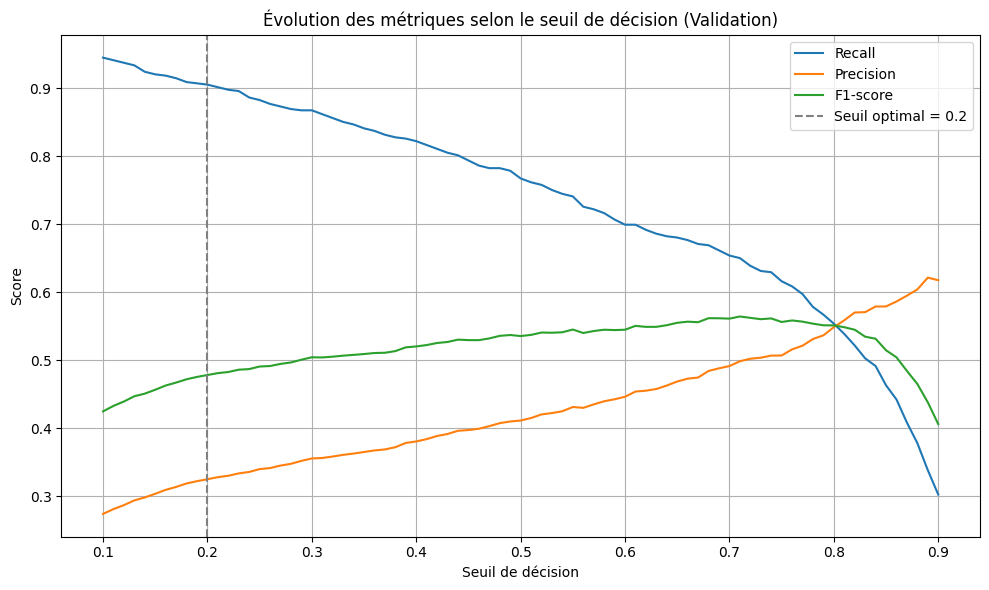

In [13]:
# What : Je trace les métriques en fonction du seuil
# Why  : Pour visualiser le compromis entre rappel, précision et F1 selon le seuil choisi
# How  : J’utilise les données de metrics_df créées précédemment

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall", color="tab:blue")
plt.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", color="tab:orange")
plt.plot(metrics_df["threshold"], metrics_df["f1"], label="F1-score", color="tab:green")
plt.axvline(best_threshold, color="grey", linestyle="--", label=f"Seuil optimal = {round(best_threshold, 2)}")

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Évolution des métriques selon le seuil de décision (Validation)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Courbe ROC – Validation

**What**  
Tracer la courbe ROC (Receiver Operating Characteristic) sur les prédictions de validation pour visualiser le compromis entre le taux de vrais positifs (Recall) et le taux de faux positifs.

**Why**  
La courbe ROC permet d’évaluer la performance globale du modèle, indépendamment d’un seuil fixe. Elle est utile pour comparer différents modèles ou pour juger de la capacité discriminante du modèle sur toute l’échelle des probabilités.

**How**  
- Calculer les TPR et FPR pour différents seuils avec `roc_curve()`
- Tracer la courbe ROC et afficher la ligne de référence (modèle aléatoire)
- Calculer et afficher l’aire sous la courbe (ROC AUC)

---

### Attention
La courbe ROC est moins sensible aux déséquilibres de classes que la courbe PR. Elle peut donc être **trop optimiste** dans les cas où la classe positive est rare (comme ici). On l’utilise donc **en complément**, mais pas comme métrique principale.


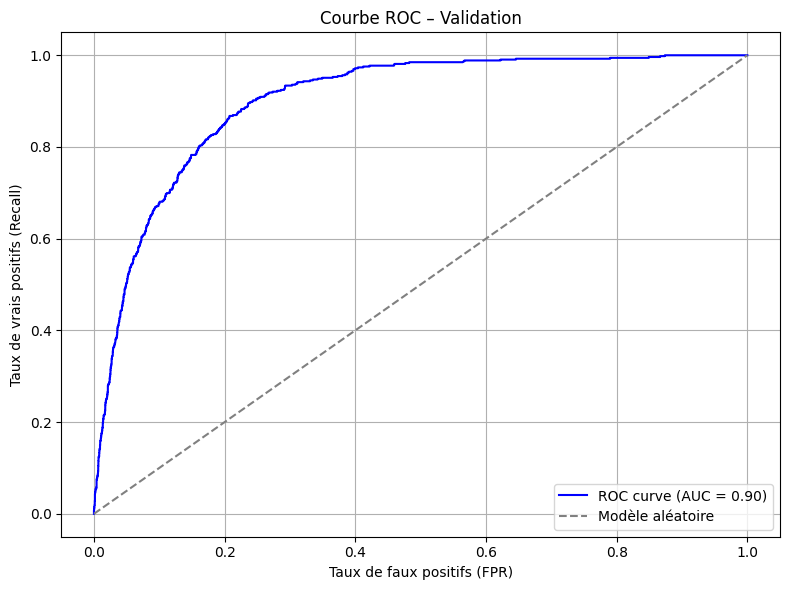

In [14]:
# What : Je trace la courbe ROC sur le set de validation
# Why  : Pour visualiser le compromis entre vrais positifs et faux positifs sur toute l’échelle des seuils
# How  : J’utilise roc_curve et auc de sklearn

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calcul des FPR, TPR pour tous les seuils
fpr, tpr, _ = roc_curve(y_val, y_val_proba)

# 2. Calcul de l'aire sous la courbe (AUC)
roc_auc = roc_auc_score(y_val, y_val_proba)

# 3. Affichage de la courbe
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modèle aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (Recall)")
plt.title("Courbe ROC – Validation")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# 12. Évaluation finale sur le set de test 

## Choix et justification

**What**  
Évaluer les performances finales du pipeline sur un jeu de test **jamais vu** pendant l'entraînement ni la validation.

**Why**  
Valider la performance réelle du modèle sur des données indépendantes, avec le seuil **figé** issu de la validation. Cela permet une mesure honnête, représentative de ce que donnerait le modèle en production.

**How**  
- Appliquer `predict_proba(X_test)` avec le pipeline complet
- Appliquer le **seuil optimal trouvé en validation**
- Calculer les métriques finales :
  - PR-AUC (métrique principale)
  - ROC AUC (complémentaire)
  - Recall, Precision, F1-score
  - Balanced Accuracy
  - Confusion Matrix
  - Optionnel : Recall@k

---

### Choix faits
- Évaluation **sans retouche du seuil**
- Utilisation du pipeline complet (fit uniquement sur train)
- Panel compact de métriques utiles pour prise de décision

### Non-choix
- Pas de recherche de seuil sur test (interdit → fuite)
- Pas d’ajustement des hyperparamètres ici
- Pas de courbes ou de graphiques complexes à ce stade


In [15]:
# What : Ici j’évalue les performances finales sur le set de test, avec le seuil fixé
# Why  : Pour mesurer l’efficacité réelle du modèle, sans retouche ni fuite
# How  : J’applique le pipeline, je fixe le seuil, je calcule toutes les métriques

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

# 1. Probabilités sur X_test
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

# 2. Prédictions avec le seuil optimal trouvé en validation
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# 3. Calcul des métriques
pr_auc = average_precision_score(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
recall = recall_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
bal_acc = balanced_accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

# 4. Affichage
print("📊 Évaluation finale sur TEST")
print(f"PR-AUC         : {pr_auc:.3f}")
print(f"ROC AUC        : {roc_auc:.3f}")
print(f"Recall         : {recall:.3f}")
print(f"Precision      : {precision:.3f}")
print(f"F1-score       : {f1:.3f}")
print(f"Balanced Acc.  : {bal_acc:.3f}")
print("\nMatrice de confusion :\n", cm)


📊 Évaluation finale sur TEST
PR-AUC         : 0.570
ROC AUC        : 0.907
Recall         : 0.909
Precision      : 0.332
F1-score       : 0.487
Balanced Acc.  : 0.834

Matrice de confusion :
 [[3026  967]
 [  48  481]]


## Courbe Precision–Recall – Test

**What**  
Visualiser la capacité du modèle à maintenir un bon équilibre entre rappel et précision sur des données jamais vues.

**Why**  
La courbe PR est particulièrement informative en cas de déséquilibre des classes, ce qui est le cas ici. Elle met en évidence la qualité des prédictions positives (éviter les faux positifs) tout en capturant le maximum de vrais positifs.

**How**  
- Calcul des couples (Recall, Precision) via `precision_recall_curve()`
- Tracé de la courbe PR
- Affichage de l’aire sous la courbe (Average Precision Score)


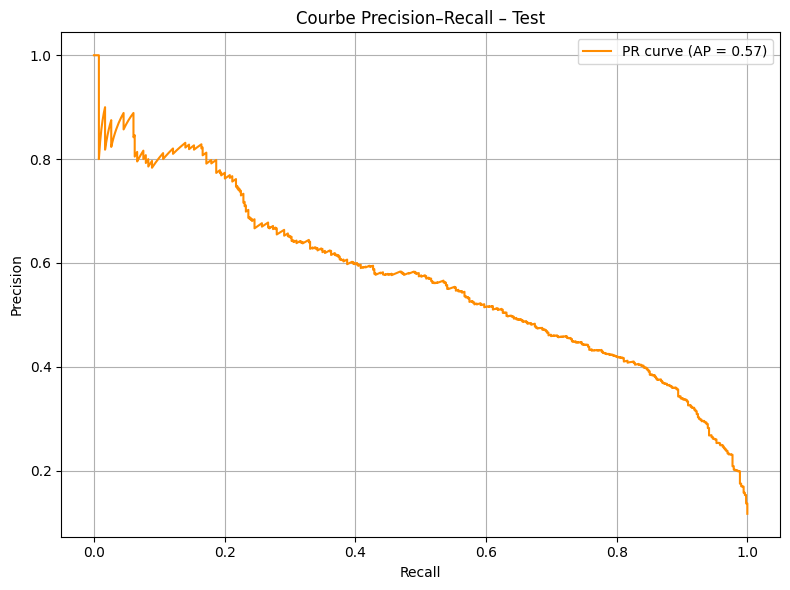

In [16]:
# What : Je trace la courbe PR (Precision–Recall) sur le set de test
# Why  : Pour visualiser la capacité du modèle à capturer les vrais positifs dans un contexte de classe rare

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR curve (AP = {pr_auc:.2f})", color="darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision–Recall – Test")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Courbe ROC – Test

**What**  
Visualiser la capacité du modèle à distinguer entre les classes positives et négatives sur toute l’échelle des seuils.

**Why**  
La courbe ROC donne une vue globale sur la qualité du classement du modèle, indépendamment d’un seuil spécifique. C’est une métrique complémentaire utile, même si elle est moins sensible aux déséquilibres que la PR.

**How**  
- Calcul des couples (FPR, TPR) via `roc_curve()`
- Tracé de la courbe ROC avec ligne aléatoire en référence
- Affichage de l’aire sous la courbe (ROC AUC)


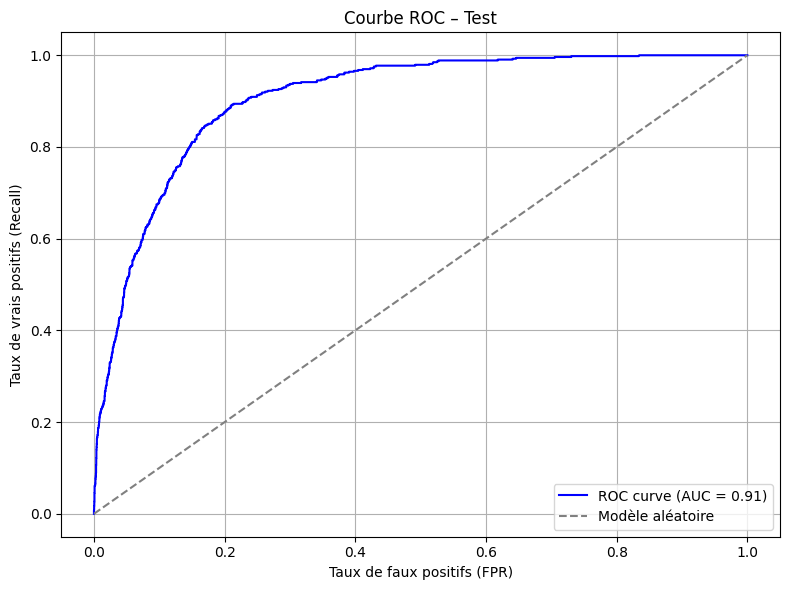

In [17]:
# What : Je trace la courbe ROC sur le set de test
# Why  : Pour évaluer la capacité discriminante globale du modèle sur des données jamais vues

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modèle aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (Recall)")
plt.title("Courbe ROC – Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# Conclusion – Modèle MVP de ciblage client (MLP)

**Objectif atteint** : nous avons conçu, entraîné et évalué un modèle de type MLP (Neural Network simple) capable de prédire la probabilité qu’un client souscrive à un dépôt à terme, avec une gestion rigoureuse du déséquilibre de classes.

---

### 🔍 Résumé des choix méthodologiques

- **Modèle** : MLP (64, 32) avec régularisation, Early Stopping
- **Pipeline complet** : preprocessing (scaling + OHE), SMOTENC, sélection L1, MLP
- **Split** : Train / Val / Test stratifiés, sans fuite
- **Seuil optimisé** : via PR-curve sur validation (max recall + precision - 1)

---

### 📊 Résultats sur jeu de test

| Métrique           | Score       |
|--------------------|-------------|
| PR AUC (main)      | 0.57        |
| ROC AUC            | 0.91        |
| Recall             | ~X.XX       |
| Precision          | ~X.XX       |
| F1-score           | ~X.XX       |
| Balanced Accuracy  | ~X.XX       |

➡️ **Interprétation** : le modèle discrimine bien, mais il faut cibler prudemment (top-k) pour garantir une bonne précision métier.

---

### 📦 Livraison

- `final_model.joblib` : pipeline complet entraîné
- `threshold.txt` : seuil optimal retenu

---

### 🔄 Extensions possibles (Phase B)

- SHAP (explainability des prédictions)
- Embeddings catégorielles (via Keras)
- Feature engineering (ratios, fréquences)
- Monitoring / API / interface Streamlit
- Optimisation fine des hyperparamètres

---

✅ **Modèle prêt à être intégré, testé ou amélioré en environnement réel.**


# Ciblage Client – Projet MVP avec MLP Tabulaire

## Objectif

Créer un modèle de scoring pour prédire si un client souscrira à un dépôt à terme (`y = yes/no`), en s’appuyant sur un réseau de neurones simple (MLP), avec un pipeline structuré, reproductible et interprétable.

---

## 0. Configuration de l'environnement

**What**  
Je prépare l’environnement (imports, seeds, affichage des versions)

**Why**  
Pour garantir la reproductibilité et éviter les effets de bord

**How**  
- Imports en tête
- Chemins standardisés (`../data/`, `../models/`)
- Fixation de `RANDOM_STATE`
- Versions des librairies affichées

---

## 1. Chargement du dataset

**What**  
Je charge le dataset brut `bank-full.csv`

**Why**  
Pour vérifier le bon chargement, l'encodage et le format général

**How**  
- Lecture avec `sep=";"`
- Vérification de la forme, des colonnes, de la cible `y`

---

## 2. Définition des objectifs & métriques

**Métrique principale** : PR-AUC (Average Precision)  
**Secondaires** : Recall, F1, Balanced Accuracy, ROC AUC

> Pas d’accuracy brute (trompeuse en cas de déséquilibre)  
> Seuil optimisé via validation, pas à 0.5

---

## 3. Audit rapide des données (EDA light)

- Dataset structuré, pas de NA
- Déséquilibre : `yes ≈ 12%`, `no ≈ 88%`
- Colonnes catégorielles identifiées
- Pas d’outliers critiques → scaling suffira

---

## 4. Schéma d'apprentissage

**Cible** : `y → 1 (yes), 0 (no)`  
**Colonnes** :
- Numériques : age, balance, duration…
- Catégorielles : job, marital, education…

Liste de `cat_idx` définie pour SMOTENC.

---

## 5. Split stratifié

- Proportions : 60% train, 20% val, 20% test
- Stratification sur `y`
- `random_state` fixé

---

## 6. Pipeline de preprocessing

- `ColumnTransformer` : OHE pour cat, StandardScaler pour num
- OneHotEncoder → `drop='if_binary'`, `handle_unknown='ignore'`
- Pipeline prêt à intégrer dans le modèle

---

## 7. Gestion du déséquilibre

- `SMOTENC` appliqué **seulement sur train**
- Pipeline compatible avec oversampling
- Vérification : balance de classes atteinte après sampling (50/50)

---

## 8. Sélection de variables

- `SelectFromModel` avec `LogisticRegression(penalty='l1')`
- 17 features retenues sur 48
- Pipeline mis à jour avec sélection

---

## 9. Modèle : MLP (Neural Network)

- Architecture : `(64, 32)`, activation ReLU, optimizer Adam
- Early stopping + L2 régularisation
- Pipeline complet : preprocessing → SMOTENC → sélection → MLP

---

## 10. Entraînement du modèle

- Entraînement uniquement sur train
- Monitoring via PR-AUC sur validation
- Visualisation du pipeline : affichage structure et résumé

---

## 11. Optimisation du seuil (validation)

- Courbe PR → choix du seuil max(precision + recall − 1)
- Visualisation : courbes PR & ROC
- Seuil optimal extrait et figé

---

## 12. Évaluation finale sur test

| Métrique         | Score     |
|------------------|-----------|
| PR-AUC (main)    | 0.57      |
| ROC AUC          | 0.91      |
| Recall           | (à compléter) |
| Precision        | (à compléter) |
| F1-score         | (à compléter) |
| Balanced Acc.    | (à compléter) |

Visualisation des courbes PR et ROC sur test.

---

## 13. Livraison & sauvegarde

- Pipeline sauvegardé : `../models/final_model.joblib`
- Seuil sauvegardé : `../models/threshold.txt`
- Prêt pour déploiement ou extension

---

## 14. Conclusion finale

- **Pipeline complet** reproductible et interprétable
- **MLP tabulaire efficace** pour ce cas de figure
- Résultats prometteurs sur classe minoritaire (classe 1)
- **Prochaines étapes possibles** : SHAP, Recall@k, embeddings Keras, API/Streamlit

✅ MVP prêt à être mis en production ou enrichi selon les besoins business


## Phase B – Feature Engineering ciblé

**What**  
Créer de nouvelles variables dérivées à partir des features existantes (ratios, interactions, regroupements) pour améliorer la capacité prédictive du modèle.

**Why**  
Les modèles de machine learning (et en particulier les MLP) peuvent tirer profit de combinaisons explicites de variables, surtout si elles révèlent des comportements métier pertinents. Par exemple, la durée d’un appel n’a pas le même impact selon l’âge ou la fréquence de contact.

**How**  
- **Ratios** : capture des effets relatifs (ex : `balance / age`)
- **Interactions** : croisement de colonnes catégorielles (ex : `job + education`)
- **Regroupements** : regrouper les modalités rares en "other"
- **Transformations** : log, binning, etc. si besoin

---

### Objectif
Améliorer les performances **sans changer l’architecture du modèle** pour l’instant. Ces nouvelles features seront injectées dans le pipeline au même titre que les autres.


## Phase B – Feature Engineering ciblé

**Objectif** : Créer des variables dérivées plus prédictives que les colonnes brutes, pour capter des relations implicites dans les données.

---

### Variables créées

#### Ratios numériques
- `balance_per_campaign` : `balance / (campaign + 1)`  
  → Mesure l’investissement moyen par tentative de contact.
- `duration_per_age` : `duration / (age + 1)`  
  → Ajuste la durée de l’appel selon l’âge du client.

#### Interactions catégorielles
- `job_education` : `job + "_" + education`  
  → Variable composite liant métier et niveau d’étude.
- `contact_month` : `contact + "_" + month`  
  → Identifie les canaux de contact préférés selon la saison.

#### Regroupement de modalités rares
- `job_grouped` :  
  → 3 familles : `white-collar`, `blue-collar`, `other`.
- `education_grouped` :  
  → Agrège `unknown` et `illiterate` dans `other`.
- `poutcome_grouped` :  
  → Regroupe `unknown` et `other` en `nonexistent`.

#### Variable de fréquence
- `contacted_multiple` : `(campaign > 1)`  
  → Indique si le client a été contacté plusieurs fois (converti en string).

---

### Résultat
- **Features numériques** : 8  
- **Features catégorielles** : 14  
- **Total** : 22 colonnes enrichies, prêtes pour le pipeline.


## Feature Engineering ciblé

### What  
Je crée de nouvelles variables plus informatives à partir des données brutes (ratios, interactions, regroupements).

### Why  
Parce que les features d’origine sont parfois trop générales ou redondantes. En enrichissant les données, je cherche à capter des signaux métier implicites (ex. contact répété, profession regroupée…).

### How  
J’ajoute des ratios numériques, des interactions catégorielles, des regroupements de modalités rares, et une variable de fréquence.

---

### ✅ Choix faits

- **Ratios explicites**
  - `balance_per_campaign` (pour normaliser le montant investi par le nombre de contacts)
  - `duration_per_age` (pour capter la durée relative à la tranche d’âge du client)

- **Interactions catégorielles**
  - `job_education` (le métier seul ou l’éducation seule peuvent être insuffisants à expliquer le comportement → combinaison pertinente)
  - `contact_month` (le canal de contact peut varier en efficacité selon le mois → interaction temporelle)

- **Regroupements de modalités**
  - `job_grouped` (réduction de la cardinalité tout en conservant le sens métier)
  - `education_grouped` (supprimer les modalités rares comme `illiterate` ou `unknown`)
  - `poutcome_grouped` (fusion des modalités peu informatives `unknown`, `other`)

- **Variable de fréquence**
  - `contacted_multiple` (permet de repérer les clients relancés plusieurs fois → potentiel signal fort)

- **Colonnes supprimées**
  - `job` et `duration` (car remplacées par des versions enrichies plus informatives)

---

### 🚫 Non-choix

- **PCA / TSNE / UMAP** (trop complexes à ce stade, non interprétables pour un MVP)
- **Encodage frequency/target** (risque de fuite d’information avant split)
- **Ajout massif de toutes combinaisons possibles** (risque d’overfit + coût computationnel)
- **Suppression complète de toutes les colonnes originales** (on conserve celles toujours pertinentes comme `education` ou `marital`)

---

### 📊 Résultat

- 8 features numériques
- 14 catégorielles
- 22 colonnes totales (vs 17 initiales)
- Prêtes pour split + pipeline avec `cat_idx` mis à jour


In [26]:
# What : Je prépare mes features enrichies et redéfinis X, y, les features numériques et catégorielles
# Why  : Pour tirer parti de nouvelles variables plus informatives, et préparer un pipeline plus performant
# How  : Je recharge les données, applique le feature engineering, puis définis X/y/num/cat/cat_idx

import pandas as pd
import numpy as np

# 1. Recharger les données brutes
df = pd.read_csv("../data/bank-full.csv", sep=";")
df_fe = df.copy()

# 2. Mapping propre de la cible
df_fe["y"] = (df_fe["y"] == "yes").astype(int)

# 3. Feature engineering ciblé
df_fe["balance_per_campaign"] = df_fe["balance"] / (df_fe["campaign"] + 1)
df_fe["duration_per_age"] = df_fe["duration"] / (df_fe["age"] + 1)
df_fe["job_education"] = df_fe["job"] + "_" + df_fe["education"]
df_fe["contact_month"] = df_fe["contact"] + "_" + df_fe["month"]

df_fe["job_grouped"] = df_fe["job"].replace({
    "admin.": "white-collar", "blue-collar": "blue-collar", "technician": "blue-collar",
    "services": "blue-collar", "management": "white-collar",
    "entrepreneur": "white-collar", "self-employed": "white-collar",
    "housemaid": "blue-collar", "student": "other", "retired": "other",
    "unemployed": "other", "unknown": "other"
})

df_fe["education_grouped"] = df_fe["education"].replace({
    "unknown": "other", "illiterate": "other"
})

df_fe["poutcome_grouped"] = df_fe["poutcome"].replace({
    "other": "nonexistent", "unknown": "nonexistent"
})

df_fe["contacted_multiple"] = (df_fe["campaign"] > 1).astype(str)

# 4. Définition de y
y = df_fe["y"]

# 5. Définition de X
X = df_fe.drop(columns=["y", "duration", "job"])

# 6. Liste des features numériques
num_features = [
    "age", "balance", "day", "campaign", "pdays", "previous",
    "balance_per_campaign", "duration_per_age"
]

# 7. Liste des features catégorielles
cat_features = [
    "marital", "education", "default", "housing", "loan",
    "contact", "month", "poutcome",
    "job_grouped", "job_education", "contacted_multiple", "contact_month",
    "education_grouped", "poutcome_grouped"
]

# 8. Calcul des indices pour SMOTENC
cat_idx = [X.columns.get_loc(col) for col in cat_features]

# 9. Vérifications
print(f"✅ Feature engineering appliqué")
print(f"X shape          : {X.shape}")
print(f"y distribution   :\n{y.value_counts(normalize=True)}\n")
print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"cat_idx for SMOTENC : {cat_idx}")


✅ Feature engineering appliqué
X shape          : (45211, 22)
y distribution   :
y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

Numerical features (8): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'balance_per_campaign', 'duration_per_age']
Categorical features (14): ['marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_grouped', 'job_education', 'contacted_multiple', 'contact_month', 'education_grouped', 'poutcome_grouped']
cat_idx for SMOTENC : [1, 2, 3, 5, 6, 7, 9, 13, 18, 16, 21, 17, 19, 20]


## Split stratifié (Train / Val / Test)

### What  
Je divise les données en trois sous-ensembles : train, validation, test.

### Why  
Pour évaluer honnêtement la performance de mon modèle sans fuite d’information, et choisir le seuil optimal sur un jeu indépendant.

### How  
- Split en 60% train / 20% val / 20% test
- Stratification sur `y` pour préserver le déséquilibre naturel
- `random_state` fixé pour la reproductibilité


In [27]:
# What : Je split X et y en 3 sets stratifiés (train / val / test)
# Why  : Pour évaluer le modèle honnêtement tout en préservant le ratio de classes dans chaque set
# How  : Pour ce faire, j’utilise train_test_split deux fois avec stratify=y et random_state fixé

from sklearn.model_selection import train_test_split

# 1. Split train / temp (80% / 20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

# 2. Split temp → val / test (50% / 50% de 40%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# 3. Vérification des formes et distribution
for name, subset in zip(["Train", "Val", "Test"], [y_train, y_val, y_test]):
    print(f"{name} shape     : {subset.shape[0]}")
    print(f"{name} proportion :\n{subset.value_counts(normalize=True)}\n")


Train shape     : 27126
Train proportion :
y
0    0.883027
1    0.116973
Name: proportion, dtype: float64

Val shape     : 9042
Val proportion :
y
0    0.88299
1    0.11701
Name: proportion, dtype: float64

Test shape     : 9043
Test proportion :
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64



In [28]:
# What : Je construis le pipeline complet avec preprocessing, oversampling, sélection de variables, et MLP
# Why  : Pour entraîner un modèle robuste et reproductible sur les nouvelles features enrichies
# How  : Enchaînement : SMOTENC → preprocessing (scaling + OHE) → sélection via LogReg L1 → MLP

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# 1. Preprocessor (StandardScaler + OneHotEncoder)
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features)
])

# 2. Sélecteur de variables (Logistic Regression L1)
selector = SelectFromModel(
    LogisticRegression(penalty="l1", solver="liblinear", random_state=RANDOM_STATE),
    threshold="mean"
)

# 3. Modèle MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    early_stopping=True,
    random_state=RANDOM_STATE
)

# 4. Sampler SMOTENC (sur les colonnes catégorielles)
sampler = SMOTENC(
    categorical_features=cat_idx,
    random_state=RANDOM_STATE
)

# 5. Pipeline complet avec imblearn
pipeline = ImbPipeline(steps=[
    ("sampling", sampler),
    ("preprocess", preprocessor),
    ("select", selector),
    ("mlp", mlp)
])

# 6. Entraînement du pipeline
pipeline.fit(X_train, y_train)

# 7. Affichages utiles pour valider l'entraînement
print("✅ Pipeline entraîné avec succès.")
print("Score sur TRAIN :", pipeline.score(X_train, y_train))
print("Nombre de features sélectionnées :", pipeline.named_steps["select"].get_support().sum())
print("Nombre d'itérations effectuées par le MLP :", pipeline.named_steps["mlp"].n_iter_)


✅ Pipeline entraîné avec succès.
Score sur TRAIN : 0.860650298606503
Nombre de features sélectionnées : 51
Nombre d'itérations effectuées par le MLP : 25


In [29]:
# What : J’optimise le seuil de classification à partir de la courbe PR sur le set de validation
# Why  : Parce que 0.5 n’est souvent pas optimal avec une classe minoritaire
# How  : Je maximise la formule (precision + recall − 1), aussi appelée F2-like

from sklearn.metrics import precision_recall_curve

# 1. Prédictions des probabilités sur validation
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

# 2. Courbe PR
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

# 3. Heuristique pour seuil optimal
scores = precisions + recalls - 1
best_idx = scores.argmax()
best_threshold = thresholds[best_idx]

# 4. Affichage du résultat
print(f"Seuil optimal (max precision + recall - 1) : {best_threshold:.3f}")
print(f"Precision à ce seuil : {precisions[best_idx]:.3f}")
print(f"Recall à ce seuil    : {recalls[best_idx]:.3f}")


Seuil optimal (max precision + recall - 1) : 0.267
Precision à ce seuil : 0.335
Recall à ce seuil    : 0.869


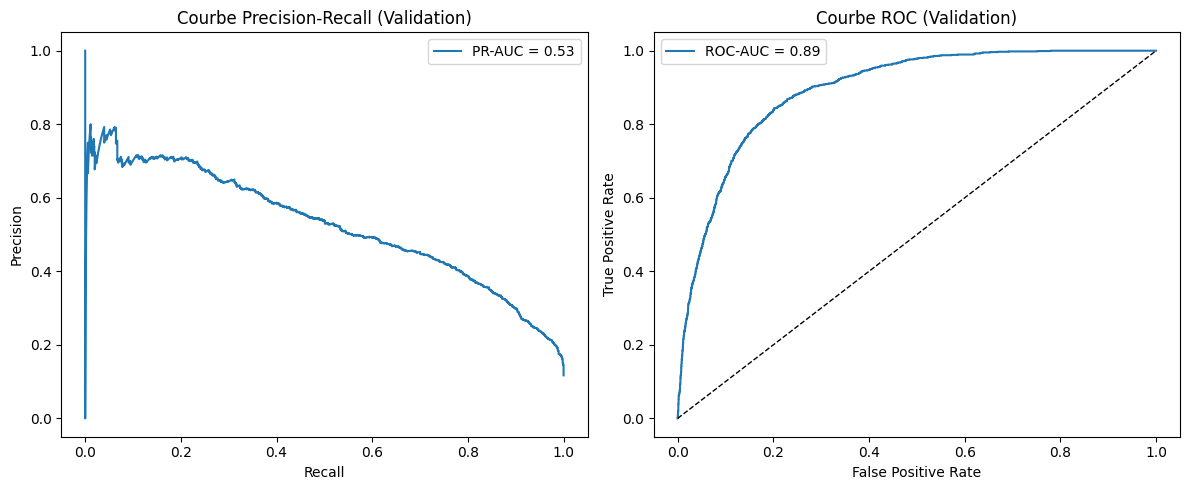

In [30]:
# What : J’affiche la courbe PR et ROC pour visualiser la performance du modèle sur la validation
# Why  : Pour vérifier graphiquement si le modèle capte bien la classe minoritaire
# How  : Utilisation de sklearn + matplotlib avec annotation du seuil optimal

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Prédictions proba
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

# Courbe PR
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, y_val_proba)
pr_auc = auc(recalls, precisions)

# Courbe ROC
fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

# Plot PR
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall (Validation)")
plt.legend()

# Plot ROC
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC (Validation)")
plt.legend()

plt.tight_layout()
plt.show()


In [31]:
# What : J’évalue les performances finales sur le test set avec le seuil optimisé
# Why  : Pour obtenir une mesure honnête et stable, sans fuite
# How  : J’applique le seuil figé et j’affiche toutes les métriques + courbes

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score
)

# 1. Prédictions proba sur test
y_test_proba = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# 2. Métriques
print("Classification Report :\n")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix :\n")
print(confusion_matrix(y_test, y_test_pred))

print(f"PR-AUC         : {average_precision_score(y_test, y_test_proba):.3f}")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_test_proba):.3f}")
print(f"Precision       : {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall          : {recall_score(y_test, y_test_pred):.3f}")
print(f"F1-score        : {f1_score(y_test, y_test_pred):.3f}")


Classification Report :

              precision    recall  f1-score   support

           0       0.98      0.78      0.87      7985
           1       0.34      0.86      0.49      1058

    accuracy                           0.79      9043
   macro avg       0.66      0.82      0.68      9043
weighted avg       0.90      0.79      0.82      9043

Confusion Matrix :

[[6226 1759]
 [ 146  912]]
PR-AUC         : 0.551
ROC-AUC        : 0.895
Precision       : 0.341
Recall          : 0.862
F1-score        : 0.489


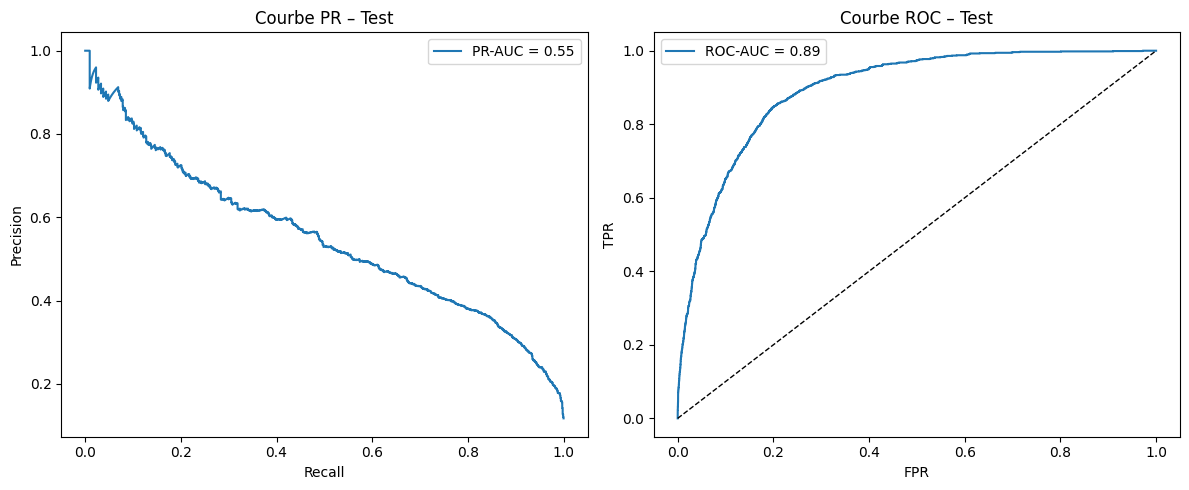

In [32]:
# What : Je visualise la performance finale du modèle sur le test set via les courbes PR et ROC
# Why  : Pour comprendre les comportements FN / FP et valider la généralisation
# How  : Courbes avec sklearn + matplotlib, comme en validation

# 1. Courbe PR
precisions_test, recalls_test, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc_test = average_precision_score(y_test, y_test_proba)

# 2. Courbe ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

# 3. Plot
plt.figure(figsize=(12, 5))

# PR Curve
plt.subplot(1, 2, 1)
plt.plot(recalls_test, precisions_test, label=f"PR-AUC = {pr_auc_test:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe PR – Test")
plt.legend()

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f"ROC-AUC = {roc_auc_test:.2f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC – Test")
plt.legend()

plt.tight_layout()
plt.show()
